In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report


df = pd.read_excel('Fires.xlsx')

In [7]:
df.head()

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
0,1,1,FS-1418826,FED,FS-FIRESTAT,FS,USCAPNF,Plumas National Forest,511,Plumas National Forest,...,A,40.036944,-121.005833,5,USFS,CA,63,63.0,Plumas,b'\x00\x01\xad\x10\x00\x00\xe8d\xc2\x92_@^\xc0...
1,2,2,FS-1418827,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,503,Eldorado National Forest,...,A,38.933056,-120.404444,5,USFS,CA,61,61.0,Placer,b'\x00\x01\xad\x10\x00\x00T\xb6\xeej\xe2\x19^\...
2,3,3,FS-1418835,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,503,Eldorado National Forest,...,A,38.984167,-120.735556,13,STATE OR PRIVATE,CA,17,17.0,El Dorado,b'\x00\x01\xad\x10\x00\x00\xd0\xa5\xa0W\x13/^\...
3,4,4,FS-1418845,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,503,Eldorado National Forest,...,A,38.559167,-119.913333,5,USFS,CA,3,3.0,Alpine,b'\x00\x01\xad\x10\x00\x00\x94\xac\xa3\rt\xfa]...
4,5,5,FS-1418847,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,503,Eldorado National Forest,...,A,38.559167,-119.933056,5,USFS,CA,3,3.0,Alpine,b'\x00\x01\xad\x10\x00\x00@\xe3\xaa.\xb7\xfb]\...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 39 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   OBJECTID                    1048575 non-null  int64  
 1   FOD_ID                      1048575 non-null  int64  
 2   FPA_ID                      1048575 non-null  object 
 3   SOURCE_SYSTEM_TYPE          1048575 non-null  object 
 4   SOURCE_SYSTEM               1048575 non-null  object 
 5   NWCG_REPORTING_AGENCY       1048575 non-null  object 
 6   NWCG_REPORTING_UNIT_ID      1048575 non-null  object 
 7   NWCG_REPORTING_UNIT_NAME    1048575 non-null  object 
 8   SOURCE_REPORTING_UNIT       1048575 non-null  object 
 9   SOURCE_REPORTING_UNIT_NAME  1048575 non-null  object 
 10  LOCAL_FIRE_REPORT_ID        301217 non-null   object 
 11  LOCAL_INCIDENT_ID           369317 non-null   object 
 12  FIRE_CODE                   223449 non-null   object 
 1

In [9]:
df.shape


(1048575, 39)

In [10]:
df.columns

Index(['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM',
       'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME',
       'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY',
       'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE',
       'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE',
       'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY',
       'FIPS_CODE', 'FIPS_NAME', 'Shape'],
      dtype='object')

In [11]:
df = df.drop(['OBJECTID','FOD_ID','FPA_ID','NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE','FIRE_NAME','ICS_209_INCIDENT_NUMBER','ICS_209_NAME','MTBS_ID','MTBS_FIRE_NAME','COMPLEX_NAME','FIPS_CODE', 'FIPS_NAME', 'Shape'], axis=1)

In [12]:
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   SOURCE_SYSTEM_TYPE     1048575 non-null  object 
 1   SOURCE_SYSTEM          1048575 non-null  object 
 2   NWCG_REPORTING_AGENCY  1048575 non-null  object 
 3   FIRE_YEAR              1048575 non-null  int64  
 4   DISCOVERY_DATE         1048575 non-null  float64
 5   DISCOVERY_DOY          1048575 non-null  int64  
 6   DISCOVERY_TIME         434827 non-null   float64
 7   STAT_CAUSE_CODE        1048575 non-null  int64  
 8   STAT_CAUSE_DESCR       1048575 non-null  object 
 9   CONT_DATE              462280 non-null   float64
 10  CONT_DOY               462280 non-null   float64
 11  CONT_TIME              425077 non-null   float64
 12  FIRE_SIZE              1048575 non-null  float64
 13  FIRE_SIZE_CLASS        1048575 non-null  object 
 14  LATITUDE          

Index(['SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY',
       'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE', 'CONT_DOY',
       'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE',
       'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY'],
      dtype='object')

In [13]:
dftimes = df[['FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME','CONT_DATE', 'CONT_DOY',
       'CONT_TIME','FIRE_SIZE', 'FIRE_SIZE_CLASS','STAT_CAUSE_DESCR']]

In [14]:
from astropy.time import Time

dftimes = dftimes.dropna(subset=['DISCOVERY_TIME'])
dftimes = dftimes.dropna(subset=['CONT_DATE'])
dftimes['DISCOVERY_DATE'] = dftimes['DISCOVERY_DATE'].apply(lambda x: Time(x, format='jd').iso)
dftimes['CONT_DATE'] = dftimes['CONT_DATE'].apply(lambda x: Time(x, format='jd').iso)   
dftimes['DISCOVERY_DATE'] = pd.to_datetime(dftimes['DISCOVERY_DATE']).dt.date
dftimes['CONT_DATE'] = pd.to_datetime(dftimes['CONT_DATE']).dt.date

In [15]:
dftimes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 413848 entries, 0 to 799485
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   FIRE_YEAR         413848 non-null  int64  
 1   DISCOVERY_DATE    413848 non-null  object 
 2   DISCOVERY_DOY     413848 non-null  int64  
 3   DISCOVERY_TIME    413848 non-null  float64
 4   CONT_DATE         413848 non-null  object 
 5   CONT_DOY          413848 non-null  float64
 6   CONT_TIME         412616 non-null  float64
 7   FIRE_SIZE         413848 non-null  float64
 8   FIRE_SIZE_CLASS   413848 non-null  object 
 9   STAT_CAUSE_DESCR  413848 non-null  object 
dtypes: float64(4), int64(2), object(4)
memory usage: 34.7+ MB


In [16]:
dftimes.head()


,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,DISCOVERY_TIME,CONT_DATE,CONT_DOY,CONT_TIME,FIRE_SIZE,FIRE_SIZE_CLASS,STAT_CAUSE_DESCR
0,2005,2005-02-02,33,1300.0,2005-02-02,33.0,1730.0,0.10,A,Miscellaneous
1,2004,2004-05-12,133,845.0,2004-05-12,133.0,1530.0,0.25,A,Lightning
2,2004,2004-05-31,152,1921.0,2004-05-31,152.0,2024.0,0.10,A,Debris Burning
3,2004,2004-06-28,180,1600.0,2004-07-03,185.0,1400.0,0.10,A,Lightning
4,2004,2004-06-28,180,1600.0,2004-07-03,185.0,1200.0,0.10,A,Lightning


In [17]:
dftimes['DISCOVERY_DATE'] = dftimes['DISCOVERY_DATE'].astype(str)
dftimes['CONT_DATE'] = dftimes['CONT_DATE'].astype(str)
dftimes['DISCOVERY_TIME'] = dftimes['DISCOVERY_TIME'].apply(lambda t: f"{int(t)//100:02d}:{int(t)%100:02d}:00")
dftimes['CONT_TIME'] = dftimes['CONT_TIME'].apply(lambda t: f"{int(t)//100:02d}:{int(t)%100:02d}:00")

# Combine date + time
dftimes['DISCOVERY_DATETIME'] = pd.to_datetime(dftimes['DISCOVERY_DATE'] + ' ' + dftimes['DISCOVERY_TIME'])
dftimes['CONT_DATETIME'] = pd.to_datetime(dftimes['CONT_DATE'] + ' ' + dftimes['CONT_TIME'])
dftimes.head()


ValueError: cannot convert float NaN to integer

In [ ]:
duration = dftimes['CONT_DATETIME'] - dftimes['DISCOVERY_DATETIME']
dftimes['DURATION'] = duration.dt.total_seconds() / 3600  

In [ ]:
dftimes.head()

,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,DISCOVERY_TIME,CONT_DATE,CONT_DOY,CONT_TIME,FIRE_SIZE,FIRE_SIZE_CLASS,STAT_CAUSE_DESCR,DISCOVERY_DATETIME,CONT_DATETIME,DURATION
0,2005,2005-02-02,33,13:00:00,2005-02-02,33.0,17:30:00,0.10,A,Miscellaneous,2005-02-02 13:00:00,2005-02-02 17:30:00,4.50
1,2004,2004-05-12,133,08:45:00,2004-05-12,133.0,15:30:00,0.25,A,Lightning,2004-05-12 08:45:00,2004-05-12 15:30:00,6.75
2,2004,2004-05-31,152,19:21:00,2004-05-31,152.0,20:24:00,0.10,A,Debris Burning,2004-05-31 19:21:00,2004-05-31 20:24:00,1.05
3,2004,2004-06-28,180,16:00:00,2004-07-03,185.0,14:00:00,0.10,A,Lightning,2004-06-28 16:00:00,2004-07-03 14:00:00,118.00
4,2004,2004-06-28,180,16:00:00,2004-07-03,185.0,12:00:00,0.10,A,Lightning,2004-06-28 16:00:00,2004-07-03 12:00:00,116.00


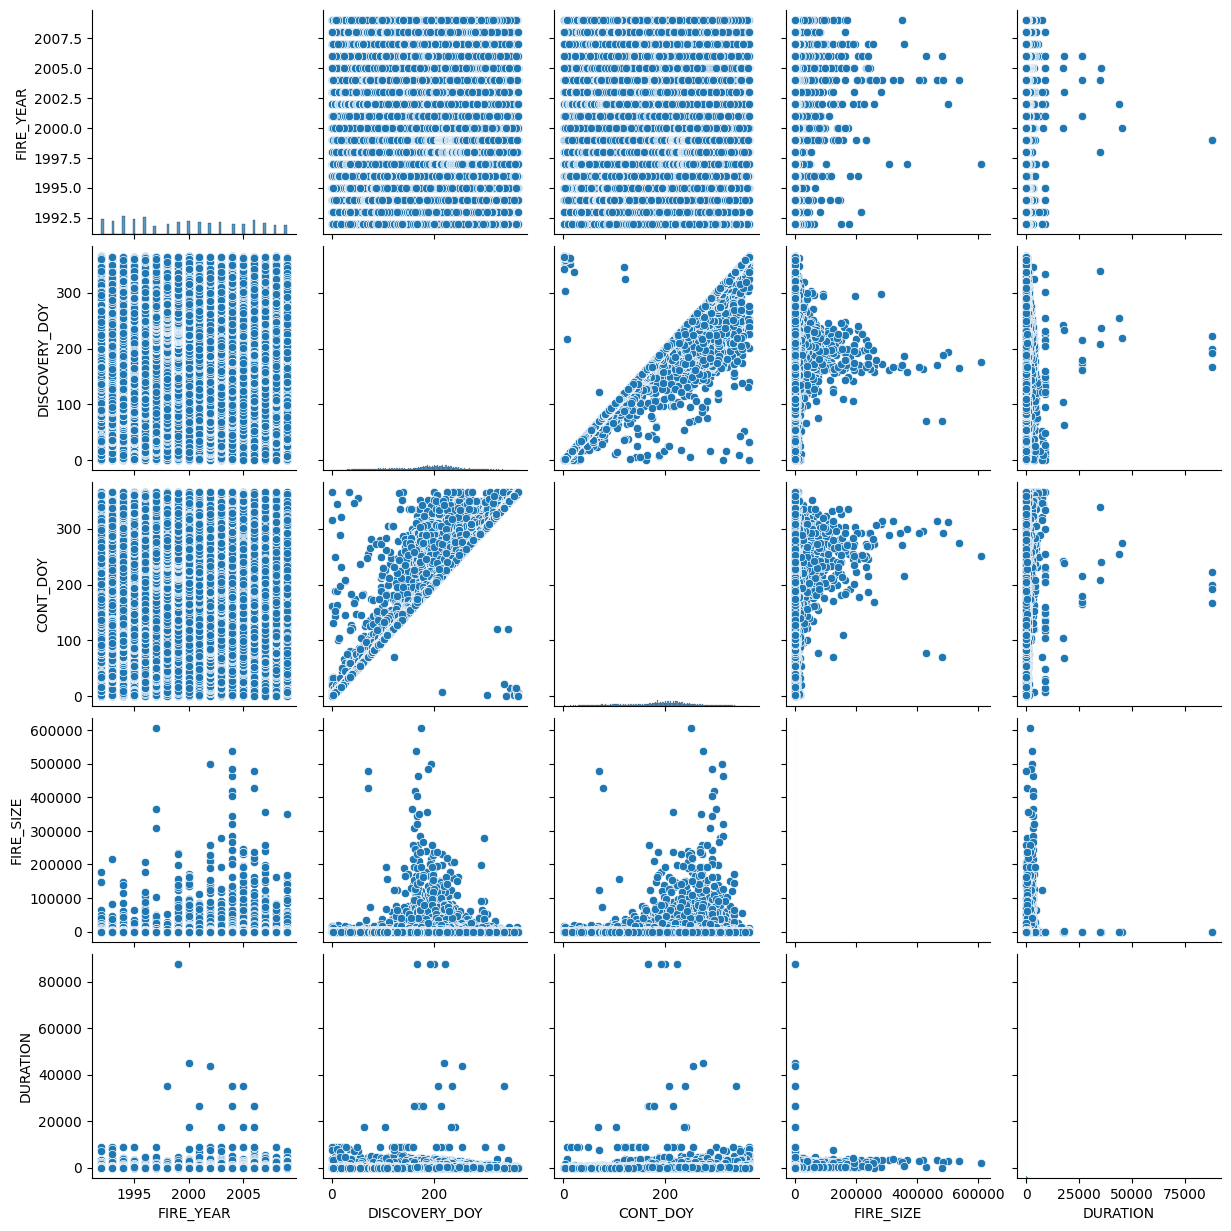

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dftimes.STAT_CAUSE_DESCR = le.fit_transform(dftimes.STAT_CAUSE_DESCR)
dftimes.STAT_CAUSE_DESCR = dftimes.STAT_CAUSE_DESCR.astype('category')
sns.pairplot(dftimes)

In [ ]:
dftimes.dtypes

FIRE_YEAR                      int64
DISCOVERY_DATE                object
DISCOVERY_DOY                  int64
DISCOVERY_TIME                object
CONT_DATE                     object
CONT_DOY                     float64
CONT_TIME                     object
FIRE_SIZE                    float64
FIRE_SIZE_CLASS               object
STAT_CAUSE_DESCR            category
DISCOVERY_DATETIME    datetime64[ns]
CONT_DATETIME         datetime64[ns]
DURATION                     float64
dtype: object

<Axes: >

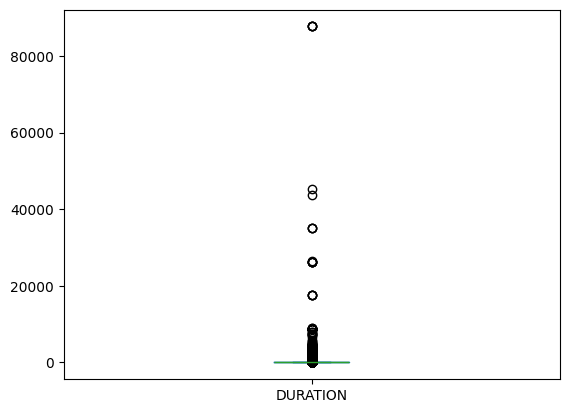

In [ ]:
dftimes['DURATION'].plot(kind='box')

In [ ]:
'''outliers = dftimes[dftimes['DURATION'] > 16000]
print(len(outliers))

'''

NameError: name 'dftimes' is not defined

In [ ]:
'''outliers = list(dftimes["DURATION"].sort_values()[-19:].index)
dftimes = dftimes.drop(outliers)'''

<Axes: >

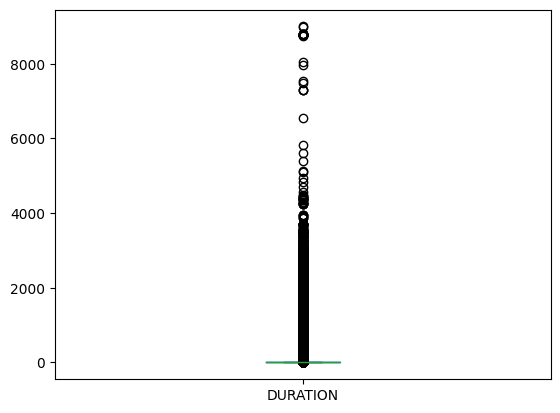

In [ ]:
#dftimes['DURATION'].plot(kind='box')

In [ ]:
'''# Filter to reasonable range (e.g. less than 1000 hours)
filtered = dftimes[dftimes['DURATION'] < 1000]
plt.figure(figsize=(10, 6))
plt.scatter(filtered['DURATION'], filtered['FIRE_SIZE'], alpha=0.5)
plt.xlabel('Containment Duration (hours)')
plt.ylabel('Fire Size (acres)')
plt.title('Fire Size vs Containment Duration (Filtered)')
plt.grid(True)
plt.tight_layout()
plt.show()'''

"# Filter to reasonable range (e.g. less than 1000 hours)\nfiltered = dftimes[dftimes['DURATION'] < 1000]\nplt.figure(figsize=(10, 6))\nplt.scatter(filtered['DURATION'], filtered['FIRE_SIZE'], alpha=0.5)\nplt.xlabel('Containment Duration (hours)')\nplt.ylabel('Fire Size (acres)')\nplt.title('Fire Size vs Containment Duration (Filtered)')\nplt.grid(True)\nplt.tight_layout()\nplt.show()"

In [ ]:

numeric_features = ['DISCOVERY_HOUR', 'LATITUDE', 'LONGITUDE', 'FIRE_YEAR']
categorical_features = ['NWCG_REPORTING_AGENCY', 'STAT_CAUSE_DESCR', 'OWNER_DESCR']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [ ]:
# Build the pipeline with preprocessing and a RandomForestClassifier
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


In [ ]:
# Train the model on the training set
pipeline.fit(X_train, y_train)

In [ ]:
# Use the trained model to predict on the test set
y_pred = pipeline.predict(X_test)


In [ ]:
# Evaluate model performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.linear_model import LogisticRegression
